<a href="https://colab.research.google.com/github/sagasucksatlife1/QuantProjects/blob/main/Monte_Carlo_Option_Simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#MONTE CARLO PRICING ENGINE

Financial derivatives such as options derive their value from the future behavior of an underlying asset. However, the future price of a stock is uncertain and cannot be predicted with certainty. Instead of attempting to forecast a single future price, Monte Carlo simulation models thousands of possible future price paths based on statistical properties of the asset.

The underlying asset price is typically assumed to follow a Geometric Brownian Motion (GBM) process, which incorporates both expected return (drift) and randomness (volatility). By repeatedly simulating the evolution of the stock price over time, we generate many possible scenarios for the asset's future value.

Example simulated paths:

Path 1: 100 → 102 → 104 → 110 → 115

Path 2: 100 → 98 → 95 → 97 → 105

Path 3: 100 → 101 → 103 → 120 → 140

Path 4: 100 → 97 → 90 → 85 → 80

For each path:

1)Calculate the option payoff

2)Average all payoffs

3)Discount back to today

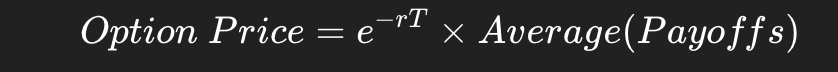

This is Monte Carlo pricing.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime

In [ ]:
stock_data = yf.download('AAPL', start='2026-01-09', end='2026-03-09')
returns = stock_data['Close'].pct_change()
annual_vol = returns.std() * np.sqrt(252)
print(annual_vol)


/tmp/ipykernel_342/1341445908.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download('AAPL', start='2026-01-09', end='2026-03-09')
[*********************100%***********************]  1 of 1 completed

Ticker
AAPL    0.2795
dtype: float64


here we have taken out the historic volatility for the past year in the apple stock that we we use as it is in the monte carlo simulation.

In [ ]:

from multiprocessing import Pool
volatility = 0.27
S_0 = 258
t = 0.285 #it's a three month option
mu = 0.05
K = 270 #strike price
steps = 126
dt = t/steps
paths = 50000
threads = 4
paths_per_thread = paths // threads


def simulate_paths(n_paths):

    payoffs = []

    for i in range(n_paths):
        S = S_0

        for j in range(steps):
            Z = np.random.normal(0,1)
            S = S * np.exp((mu - 0.5*volatility**2)*dt + volatility*np.sqrt(dt)*Z)

        payoff = max(S - K, 0)
        payoffs.append(payoff)
    return payoffs

if __name__ == "__main__":

    with Pool(threads) as p:
        results = p.map(simulate_paths, [paths_per_thread]*threads)

    payoffs = np.concatenate(results)

    price = np.exp(-mu*t) * np.mean(payoffs)
    print("Option price:", price)

Option price: 11.407520039121382


Here we run our first simulation of monte carlo pricing engine where we have used the simuated geometric browninan motion equation which is the solution of the stocastic differntial equation of geometric brownian motion solved using Ito's Lemma.
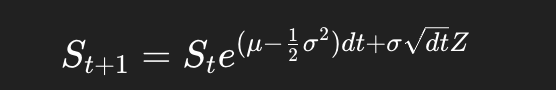

I have also added the concept of parallel programming... Personally i wanted to use openMP but as i was writing the code in python... thus the Mutiprocessing library is used here from python.

This is used to calculate the price of a Vanilla option, its payoff is simply the value of the option over the strike price K and since the value cannot be neagtive as the holder wont exercise the option unless its not profitable. We have taken the MAX along side 0.

In [ ]:
std_error = np.std(payoffs) / np.sqrt(paths)
ci = 1.96 * std_error
print(f"95% confidence interval: {price - ci} to {price + ci}")

95% confidence interval: 11.21957944358575 to 11.595460634657012


After the price was calculated that came out to 11.40. we caluated it for the error. where the law of large umbers comes it stating that the higher the observation th ecloser the estimation raeches ariund the actual value of the option.

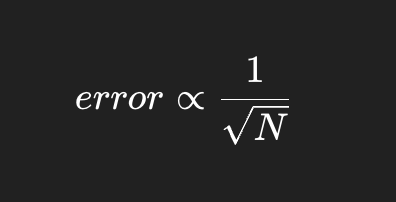

We also stated a 95% confidence interval and that gave us the range of where the value of the actual option could be as the Current value of the option could be checked online the value was 11.41 thus we can say the the value of the option was perfectly price or the value of the option is minimally overpriced but not a Spread worth trading.

In [ ]:
from multiprocessing import Pool
volatility = 0.27
S_0 = 258
t = 0.285 #it's a three month option
mu = 0.05
K = 270 #strike price
steps = 126
dt = t/steps
paths = 50000
threads = 4
paths_per_thread = paths // threads


def simulate_paths_asian_option(n_paths):

    payoffs = []

    for i in range(n_paths):
        S = S_0
        price = []

        for j in range(steps):
            Z = np.random.normal(0,1)
            S = S * np.exp((mu - 0.5*volatility**2)*dt + volatility*np.sqrt(dt)*Z)
            price.append(S)
        avg_price = np.mean(price)
        payoff = max(avg_price - K, 0)
        payoffs.append(payoff)

    return payoffs

if __name__ == "__main__":

    with Pool(threads) as p:
        results = p.map(simulate_paths_asian_option, [paths_per_thread]*threads)

    payoffs = np.concatenate(results)

    price = np.exp(-mu*t) * np.mean(payoffs)
    print("Option price for asian options:", price)

Option price for asian options: 4.606151323054369


Since we have ran a sampl,e maonte carlo and the aim of the project was proper implementation of this strategy at an Advanced level, we went further iin depth to calculate the price od Exotic option...

Since most of these options are sold OTC method (over-the-counter) i cannot confirm wether the spread it tradable or not.

In the piece of code i have used the monte carlo to find the price of asian options ...

The differnce btw Asian options and the Vanilla options is the asian option do not derive their value at exercise Date like the vanilla options, where the price at the expiration is what u get (price-K). Asian options are meant with the sole purpose to safe-guard the company from final day price manupulation and thus the price of the options is the avegrae price of teh option through its life (avg price of the option - K).

Thus the only change here is the creation of an empty list that records the price through its life on daily intervals and at the end the payy is calculated by -

           avg_price = np.mean(price)
        
           payoff = max(avg_price - K, 0)


The price of this option is lower than that of the vanilla options and is equal to 4.606151323054369.

In [ ]:

from multiprocessing import Pool
volatility = 0.27
S_0 = 258
t = 0.285 #it's a three month option
mu = 0.05
K = 270 #strike price
barrier = 300
steps = 126
dt = t/steps
paths = 50000
threads = 4
paths_per_thread = paths // threads


def simulate_paths_Barrier_option(n_paths):

    payoffs = []

    for i in range(n_paths):
        S = S_0
        takedown = False

        for j in range(steps):
            Z = np.random.normal(0,1)
            S = S * np.exp((mu - 0.5*volatility**2)*dt + volatility*np.sqrt(dt)*Z)
            if S > barrier:
                takedown = True
        if takedown == True:
          payoff = 0
        else :
          payoff = max(S - K, 0)

        payoffs.append(payoff)

    return payoffs

if __name__ == "__main__":

    with Pool(threads) as p:
        results = p.map(simulate_paths_Barrier_option, [paths_per_thread]*threads)

    payoffs = np.concatenate(results)

    price = np.exp(-mu*t) * np.mean(payoffs)
    print("Option price for Barrier options:", price)

Option price for Barrier options: 1.5092007015868654


Here is another type of Exotic option called the Barrier option. the sole purpose of this option is that banks sell it as its cheap and poeple with insuffiecnt funds can buy these options...

What these options are is simple, u buy the option and set a barrier when ever throughout the life of the option the price of the option crosses the barrier value the option contract is terminated and the preminum is lost.... Even before the expiration date.

The price of the Barrier soley depends on the bolatility of the market and the diffence btw the currrent price the stike price and the barrier... Higher the barrier the less the probablity that option will be taken-down. thus higher the Price.

We have taken a takedown as intally false when the S crosses the take down the value of the option is null and if it doest the price of the otpion stays liek the vanilla option.

OBSERVATION - when the barrier price is closer to the strike price, the value of the option is very less.. example

STRIKE - 270,
BARRIER - 300

Option price = 1.5092007015868654

But if the value of the barrier is so reasobly high that the pprobabilty of reaching that option is close to null the barrier option price converge with the price of the vanilla option.

example-

STRIKE - 270,
BARRIER - 1000

Option price: 11.407520039121382, which is the same as that of the vanilla that we calculated before.



In [ ]:

from multiprocessing import Pool
volatility = 0.27
S_0 = 258
t = 0.285 #it's a three month option
mu = 0.05
K = 270 #strike price
steps = 126
dt = t/steps
paths = 50000
threads = 4
paths_per_thread = paths // threads


def simulation_of_milstein_model(n_paths):
  payoffs=[]
  for i in range(n_paths):
    S = S_0
    for j in range(steps):
      Z = np.random.normal(0,1)

      S = S + mu*S*dt + volatility*S*np.sqrt(dt)* Z + 0.5*volatility**2*S*(Z**2-1)*dt

    payoff = max(S - K, 0)
    payoffs.append(payoff)
  return payoffs

if __name__ == "__main__":

    with Pool(threads) as p:
        results = p.map(simulation_of_milstein_model, [paths_per_thread]*threads)

    payoffs = np.concatenate(results)

    price = np.exp(-mu*t) * np.mean(payoffs)

    std_error = np.std(payoffs) / np.sqrt(paths)

    print("Milstein Vanilla Option Price:", price)
    print("Standard Error:", std_error)

Milstein Vanilla Option Price: 11.405756299418162
Standard Error: 0.09587436921086334


In all the cases before this we were using the direct solution of the geometric brownian motion but there are other ways to solve the stocastic diffrential eqn like euler method

 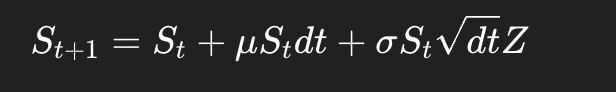


And for being more precise Milstein method which is an extension of the eulers method but the randomness term had be expanded using the Ito's Lemma.




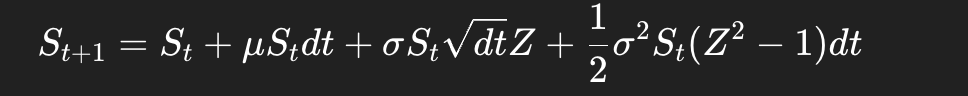

Rather than directly genrating paths using the S-GBM. we use Milstein method to genrate the point be looping ove rthe value of S. Than using the simple vanilla option to comapare the price differnce.

Observation - Both the method give similar values with little differnce proving the point that the stocastic differntial eqn can be solved directly by the above methods.

Infact the price of the option estimated by this method is 11.593670063071453 which is much closer to the actual price

In [ ]:
std_error = np.std(payoffs) / np.sqrt(paths)
ci = 1.96 * std_error
print(f"95% confidence interval: {price - ci} to {price + ci}")

95% confidence interval: 11.21784253576487 to 11.593670063071453


In [ ]:


from multiprocessing import Pool
volatility = 0.27
S = 258
t = 0.285 #it's a three month option
mu = 0.05
K = 270 #strike price
steps = 126
dt = t/steps
paths = 50000
threads = 4
paths_per_thread = paths // threads


def simulate_paths(n_paths):

    payoffs = []

    for i in range(n_paths):
        S1 = S
        S2 = S

        for j in range(steps):
            Z = np.random.normal(0,1)

            S1 = S1 * np.exp((mu - 0.5*volatility**2)*dt + volatility*np.sqrt(dt)*Z)
            S2 = S2 * np.exp((mu - 0.5*volatility**2)*dt + volatility*np.sqrt(dt)*-Z)

        payoff_1 = max(S1 - K, 0)
        payoff_2 = max(S2 - K, 0)

        payoff = (payoff_1 + payoff_2)/2
        payoffs.append(payoff)

    return payoffs

if __name__ == "__main__":

    with Pool(threads) as p:
        results = p.map(simulate_paths, [paths_per_thread]*threads)

    payoffs = np.concatenate(results)

    price = np.exp(-mu*t) * np.mean(payoffs)
    print("Option price:", price)


Option price: 11.31456170620018


Even though the monte carlo method is givng us good results, it still genrates noise data that can be reduced by the method of Antithetic pairing where the random value of Z that we genrate we take a value -Z for it then calculte two diff S - S1,S2 and the final S will be avg of the both.

This way we can significantly reduce the noise generated by the Monte-Carlo Method.

In [ ]:
std_error = np.std(payoffs) / np.sqrt(paths)
print("Vanilla Option Price using Antithetic pair:", price)
print("Standard Error:", std_error)
ci = 1.96 * std_error
print(f"95% confidence interval: {price - ci} to {price + ci}")

Vanilla Option Price using Antithetic pair: 11.31456170620018
Standard Error: 0.056359790597581554
95% confidence interval: 11.20409651662892 to 11.42502689577144


In [ ]:
from multiprocessing import Pool
import numpy as np
volatility = 0.27
S_0 = 258
t = 0.285
mu = 0.05
K = 270
steps = 126
dt = t/steps
threads = 4

def simulate_paths(n_paths):

    payoffs = []
    for i in range(n_paths):
        S = S_0

        for j in range(steps):
            Z = np.random.normal(0,1)
            S = S * np.exp((mu - 0.5*volatility**2)*dt + volatility*np.sqrt(dt)*Z)

        payoff = max(S - K, 0)
        payoffs.append(payoff)
    return payoffs

if __name__ == "__main__":
    path_list = [100, 1000, 5000, 10000, 50000,100000]
    for path in path_list:
        paths_per_thread = path // threads

        with Pool(threads) as p:
            results = p.map(simulate_paths, [paths_per_thread]*threads)
        payoffs = np.concatenate(results)
        price = np.exp(-mu*t) * np.mean(payoffs)
        print(f"Paths: {path}  Option price: {price}")

Paths: 100  Option price: 15.825081190817869
Paths: 1000  Option price: 12.821101860317622
Paths: 5000  Option price: 11.74652307996554
Paths: 10000  Option price: 11.42636859918136
Paths: 50000  Option price: 11.407520039121382
Paths: 100000  Option price: 11.41460023857765


Lastly we have genrated a convergence graph to prove the law of large number in our model. where have taken mutiple paths with diff no of observation...100, 1000, 5000, 10000, 50000, 100000

We have seen that as the nuber of observation increases the estimated value converges with the true value proving the Law of large numbers and validating our Monte carlo Pricing Engine.

Below is the graphical representaion of the same.

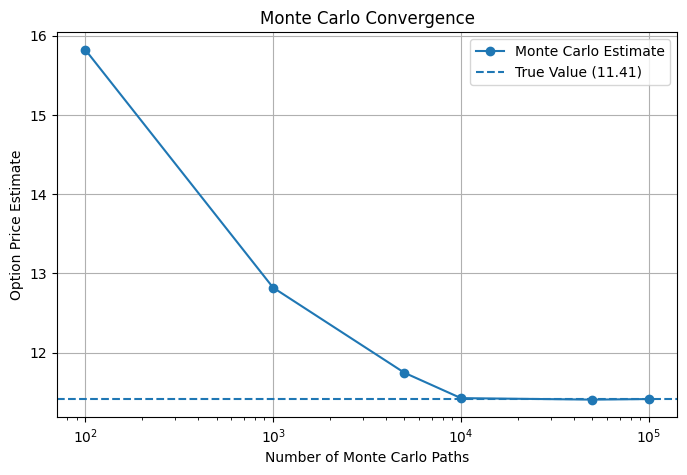

In [ ]:
import matplotlib.pyplot as plt

paths = [100, 1000, 5000, 10000, 50000, 100000]
prices = [
    15.825081190817869,
    12.821101860317622,
    11.74652307996554,
    11.42636859918136,
    11.407520039121382,
    11.41460023857765
]

true_value = 11.41

plt.figure(figsize=(8,5))

plt.plot(paths, prices, marker='o', label="Monte Carlo Estimate")
plt.axhline(true_value, linestyle='--', label="True Value (11.41)")

plt.xscale("log")  # helps visualize large path differences

plt.xlabel("Number of Monte Carlo Paths")
plt.ylabel("Option Price Estimate")
plt.title("Monte Carlo Convergence")
plt.legend()
plt.grid(True)

plt.show()

I could have created one fucntions and staked the pricing engines in them like

simulate_gbm(),
simulate_milstein()

price_vanilla(),
price_asian(),
price_barrier()

But it would have been a night mare explaining the code as i have done ... the code would have been extremly big block and the explation block would be one big block as well....

There are efficent ways to execture this engine, I agree but the following flow is the best to learn and document so I went with it.